Deposit market clearing: 0.9897794132001582


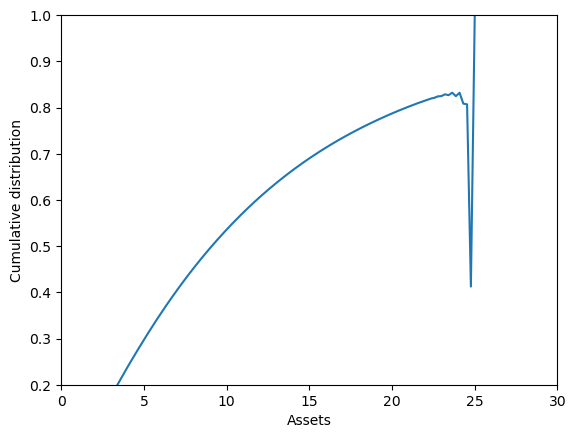

{'frisch': 1.0, 'eis': 0.5, 'habit': 0.0, 'C_lag': 0.0, 'rdep': 0.0065, 'rb': 0.005, 'B_supply': 2.4, 'T': 0.15, 'phi_T': 0.06, 'Y': 1.0, 'N': 1.0, 'w': 0.65, 'f': 0.06, 'lambda_gk': 0.116, 'ksi': 0.5, 'n_inter': 3.0, 'theta': 4, 'alpha': 0.35, 'delta': 0.0125, 'nZ': 19, 'nDep': 500, 'Depmax': 25, 'rho_z': 0.9, 'sigma_z': 0.5, 'Q': 1.0, 'b_gov': 0.6, 'b_gov_ss': 0.6, 'T_ss': 0.15, 'beta': 0.9897794132001582, 'K': 12.0, 'rk': 0.016666666666666663, 'rn': 0.045966666666666656, 'm': 0.05037400000000014, 'k_inter': 12.0, 'I': 0.15000000000000002, 'D_supply': 11.4, 'G': 0.13799999999999998, 'Z': 0.4190699921000142, 'rdep_ante': 0.0065, 'div': 0.13789999999999997, 'iota': 0.0125, 'mpk': 0.029166666666666664, 'Omega': 0.44818954307175346, 'nu': 0.004510022626597405, 'eta': 0.44649224003314314, 'gamma0': 0.22360679774997896, 'gamma1': -0.0125, 'DEP': np.float64(11.400000001226646), 'C': np.float64(0.711999989811907), 'UCE': np.float64(2.349696699428718), 'SDF': 0.9897794132001583, 'goods_mkt': 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np
import scipy.linalg
import os

from pathlib import Path
import numpy as np
import scipy.linalg
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR = Path.cwd()

# REMOVE .parent here. 
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR = BASE_DIR / "Discretisation" / "Outputs"


calibration_start = {

    #==> Household parameters (single deposit asset) efe
    'frisch': 1.0,    # Frisch elasticity of labour supply (1/varphi)
    'eis': 0.5,       # Intertemporal elasticity of substitution (1/sigma)
    'habit': 0.00,    # Habit formation parameter (h)
    'C_lag': 0.0,     # Previous Consumption

    #==> Deposit rate 
    'rdep': 0.0065,

    #==> Bond rate
    'rb': 0.005,

    #==> Government bonds
    'B_supply': 0.6*4,

    #==> Policy parameters
    'T': 0.15,         # Linear tax on labour income
    'phi_T': 0.06,     # Fiscal adjustment rule

    ##==> Aggregate targets
    'Y':  1.00,
    'N':  1.00,
    'w':  0.70,

    ##==> Financial intermediary
    'f': 0.06,
    'lambda_gk': 0.116,
    'ksi': 0.5,                  # Capital adjustment cost
    'n_inter': 0.75*4,             # Financial intermediary net worth
    'theta':   4,                # Capital leverage (k_inter / n_inter)

    #==> Production
    'alpha': 0.35,               # Capital share in production
    'delta': 0.0125,             # Depreciation rate (quarterly)

    #==> Deposit grid (single asset)
    'nZ': 19,                       # Matrix loads with 19 Number of income states
    'nDep': 500,                    # Number of deposit grid points
    'Depmax': 25,                 # Maximum deposits

    #==> Not used unless nZ != 19
    'rho_z': 0.9,
    'sigma_z': 0.5,

    #==> Tobin's q (= 1 in steady state with standard adjustment cost calibration)
    'Q': 1.0,

    #==> Government bonds outstanding (= B_supply at SS) and fiscal-rule anchors
    'b_gov':   0.6,    # = B_supply
    'b_gov_ss': 0.6,   # SS anchor used in tax rule
    'T_ss':    0.15,   # SS tax rate anchor used in tax rule
}

calibration_hh = {
    **calibration_start,

    #==> Calibrated so deposit market clears
    'beta': 0.9705546368050272,

    #==> Dividend income (bank equity return to HH) in steady state
    'div': 0.20,
}



# 1. Initialize Household
def hh_init(dep_grid, z, rdep, eis):
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    Vdep = (1 + rdep) * coh ** (-1 / eis)
    return Vdep

# 2. Backward Step (HH Block)
@sj.het(exogenous='Pi', policy='dep', backward='Vdep', backward_init=hh_init)
def hh(Vdep_p, dep_grid, z, rdep, beta, eis):
    uc_nextgrid = beta * Vdep_p
    c_nextgrid = uc_nextgrid ** (-eis)
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    
    # Policy iteration
    dep = sj.interpolate.interpolate_y(c_nextgrid + dep_grid, coh, dep_grid)
    sj.misc.setmin(dep, dep_grid[0])
    
    c = coh - dep
    uce = c ** (-1 / eis)        # marginal utility; UCE aggregate needed by sdf block
    Vdep = (1 + rdep) * uce
    return Vdep, dep, c, uce

# 3. Grids and Income
def make_grids(Depmax, nDep, nZ, rho_z, sigma_z):
    """Single-asset (deposit) grid — no illiquid or capital grid."""
    dep_grid = grids.agrid(amax=Depmax, n=nDep)

    if nZ == 19:
        # Construct paths safely
        px_path = DATA_DIR / "Px_GMAR.txt"
        x_path = DATA_DIR / "x_vec.txt"
        markov_ctstime = np.loadtxt(px_path)
        e_grid = np.loadtxt(x_path).flatten()       
        markov_distime = scipy.linalg.expm(markov_ctstime)
        row_sums = markov_distime.sum(axis=1)
        Pi = markov_distime / row_sums[:, None]
    else:
        e_grid, _, Pi = grids.markov_rouwenhorst(rho=rho_z, sigma=sigma_z, N=nZ)

    return dep_grid, e_grid, Pi





def income(e_grid, w, div, T):
    # Standard HANK income: idiosyncratic productivity × real wage.
    # Z reaches households through w (labor block: w=(1-α)Y/N, N depends on Z),
    # so Z→labor→w→income→C is the transmission path without Z here directly.
    z = w * e_grid +div - T
    return z

hh_extended = hh.add_hetinputs([make_grids, income])

# 4. Steady State & Market Blocks
@simple
def smart_steady(theta, Y, T, n_inter, rdep, alpha, delta, f, N, B_supply, rb):
    K        = theta * n_inter
    phi_b    = B_supply / n_inter
    rk       = alpha * Y / K - delta
    rn       = theta * (rk - rdep) + phi_b * (rb - rdep) + rdep
    m        = n_inter * (1 - (1 - f) * (1 + rn))
    k_inter  = K
    I        = K * delta
    D_supply = (theta - 1) * n_inter + B_supply
    G        = T - rb * B_supply
    Z        = Y / ((K ** alpha) * (N ** (1 - alpha))) # Fixed: Changed Ze to Z
    rdep_ante  = rdep
    return K, rk, rn, m, k_inter, I, D_supply, G, Z, rdep_ante

@simple
def market_clearing(Y, C, I, G, DEP, n_inter, theta, B_supply, div):
    # 'DEP' comes from the hh_extended block aggregate
    goods_mkt   = Y - C - I - G
    deposit_mkt = DEP - ((theta - 1) * n_inter + B_supply)
    return goods_mkt, deposit_mkt

@simple
def steady_auxilliary(theta, rk, rdep, delta, alpha, Y, K, N, lambda_gk, beta, ksi, rn):
    iota   = delta
    mpk    = alpha * (Y / K)
    w      = (1 - alpha) * Y / N
    Omega  = theta * lambda_gk / (beta * (1 + rn))
    nu     = beta * Omega * (rk - rdep)
    eta    = beta * Omega * (1 + rdep)
    gamma0 = delta ** ksi / (1 - ksi)
    gamma1 = -delta * ksi / (1 - ksi)
    return iota, mpk, w, Omega, nu, eta, gamma0, gamma1

@simple
def banker_div(rn, n_inter):
    div = rn * n_inter
    return div

@simple
def sdf(beta, UCE):
    SDF = beta * UCE(+1) / UCE
    return SDF

# 5. Create Model
ha = sj.create_model([hh_extended, smart_steady, market_clearing, steady_auxilliary, banker_div, sdf], name="Simple HA Model")

# 6. Solve Steady State
# Ensure calibration_start contains all required inputs (theta, Y, n_inter, etc.)
unknowns_ss = {'beta': (0.96, 0.99)} 
targets_ss  = ['deposit_mkt']

ss = ha.solve_steady_state(
    calibration_start, 
    unknowns_ss, 
    targets_ss, 
    solver='bisect' # Use bisect for 1D stable solving
)

print(f"Deposit market clearing: {ss['beta']}")

D = ss.internals['hh']['D'].sum(axis=0)
dep_grid = ss.internals['hh']['dep_grid']
plt.plot(dep_grid, D.cumsum())
plt.ylim([0.2, 1])
plt.xlim([0, 30])
plt.xlabel('Assets')
plt.ylabel('Cumulative distribution')
plt.show()


cali = ss
calibration = dict(ss)






# ── Off-Steady-State Equations ────────────────────────────────────────────────
@simple
def capital_adj(Y, K, Q, I, alpha, delta, gamma0, gamma1, ksi, Z):
    iota        = I / K(-1)
    mpk         = alpha * Y / K(-1)
    rk          = (mpk + (1 - delta) * Q) / Q(-1) - 1
    q_res       = Q - 1 / (gamma0 * (1 - ksi) * iota ** (-ksi)) +0*Z
    capital_res = K - (1 - delta) * K(-1) - (gamma0 * iota ** (1 - ksi) + gamma1) * K(-1) +0*Z
    return iota, mpk, rk, q_res, capital_res



@simple
def intermediation_IC(nu, eta, lambda_gk):
    theta = eta / (lambda_gk - nu)
    return theta


@simple
def bank_return(theta, rk, rdep, b_gov, n_inter, rb):
    # phi_b is predetermined (lagged balance-sheet ratio)
    phi_b_lag = b_gov(-1) / n_inter(-1)
    rn = theta(-1) * (rk - rdep) + phi_b_lag * (rb - rdep) + rdep
    return rn


@simple
def intermediation_P1(rk, rdep, nu, lambda_gk, eta, theta, SDF, f):
    # Bellman equations: bankers fund at deposit rate rd
    Omega_p1 = f + (1 - f) * lambda_gk * theta(+1)
    nu_res   = nu  - SDF * Omega_p1 * (rk(+1) - rdep(+1))
    eta_res  = eta - SDF * Omega_p1 * (1 + rdep(+1))
    return nu_res, eta_res

# K = theta * n_inter is the bank balance-sheet identity.
# Keeping it separate (not inside intermediation_P1) lets K be an outer unknown
# so capital_adj can use K without creating a cycle with intermediation_ne_solved.
@simple
def k_balance_sheet(theta, n_inter, K):
    K_res = K - theta * n_inter
    return K_res


@simple
def intermediation_P2(rn, n_inter, m, f):
    n_inter_val = (1 - f) * (1 + rn) * n_inter(-1) + m - n_inter
    return n_inter_val


@simple
def intermediation_P3(theta, n_inter, b_gov):
    D_supply = (theta - 1) * n_inter + b_gov
    return D_supply


@simple
def government(T, rb, b_gov):
    G = T - (1 + rb) * b_gov(-1) + b_gov
    return G


@simple
def tax_rule(b_gov, T_ss, b_gov_ss, phi_T):
    T = T_ss + phi_T * (b_gov(-1) - b_gov_ss)
    return T

@simple
def budget_residual(b_gov, G, T, rb):
    b_gov_res = (1 + rb) * b_gov(-1) + G - T - b_gov
    return b_gov_res


@simple
def rk_from_production(Y, K, alpha, delta):
    # rk at t uses capital chosen at t-1 (standard timing)
    rk = alpha * Y / K(-1) - delta
    return rk


@simple
def labor(K, Z, alpha, N):
    # Y is now driven by TFP and Capital!
    Y = Z * K(-1) ** alpha * N ** (1 - alpha)
    w = (1 - alpha) * (Y / N)
    return Y, w



print(calibration)


In [12]:
@simple
def intermediation_P2(rn, n_inter, m, f):
    n_inter_val = (1 - f) * (1 + rn) * n_inter(-1) + m - n_inter
    return n_inter_val

@simple
def banker_div_res(rn, n_inter, div):
    # This evaluates how wrong the outer solver's guess for 'div' is
    div_res = div - rn * n_inter
    return div_res


# We only solve for the forward-looking variables internally
financial_solved = combine([
    intermediation_IC,
    intermediation_P1,
]).solved(
    unknowns={
        'nu':  float(cali['nu']),
        'eta': float(cali['eta']),
    },
    targets=['nu_res', 'eta_res'],
    solver='broyden_custom'
)

print("financial_solved inputs: ", financial_solved.inputs)
print("financial_solved outputs:", financial_solved.outputs)



# Assemble all blocks. The DAG will now sort perfectly.
ha_full = sj.create_model([
    hh_extended,
    financial_solved,
    bank_return,
    intermediation_P2,  # Your original block that outputs 'n_inter_val'
    intermediation_P3,
    k_balance_sheet,
    capital_adj,
    sdf,
    tax_rule,
    budget_residual,
    labor,
    banker_div_res,     # Our new residual block
    market_clearing
], name="Full HANK Model")

# 'Y' is replaced by 'rdep_ante', 'b_gov' is added
unknowns_tp = ['rdep', 'K', 'n_inter', 'div', 'I', 'Q', 'b_gov']

# 'b_gov_res' is added to ensure the fiscal budget clears
targets_tp  = ['goods_mkt', 'K_res', 'n_inter_val', 'div_res', 'capital_res', 'q_res', 'b_gov_res']

T = 300 
exogenous = ['Z']

print(f"Computing Jacobian for horizon T={T}...")
G = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)





financial_solved inputs:  ['lambda_gk', 'rk', 'rdep', 'SDF', 'f']
financial_solved outputs: ['theta', 'nu_res', 'eta_res', 'nu', 'eta']
Computing Jacobian for horizon T=300...


In [16]:
# ── 4. Impulse Response Functions (TFP Shock) ───────────────────────
rho_Z = 0.9
dZ = 1 * rho_Z ** np.arange(T)
shocks = {'Z': dZ}

print("Computing linear impulse responses...")
irfs = ha_full.solve_impulse_linear(ss, unknowns_tp, targets_tp, shocks)


Computing linear impulse responses...


In [19]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=40, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            ax[i].plot(irf[variables[i]][:T_plot], label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

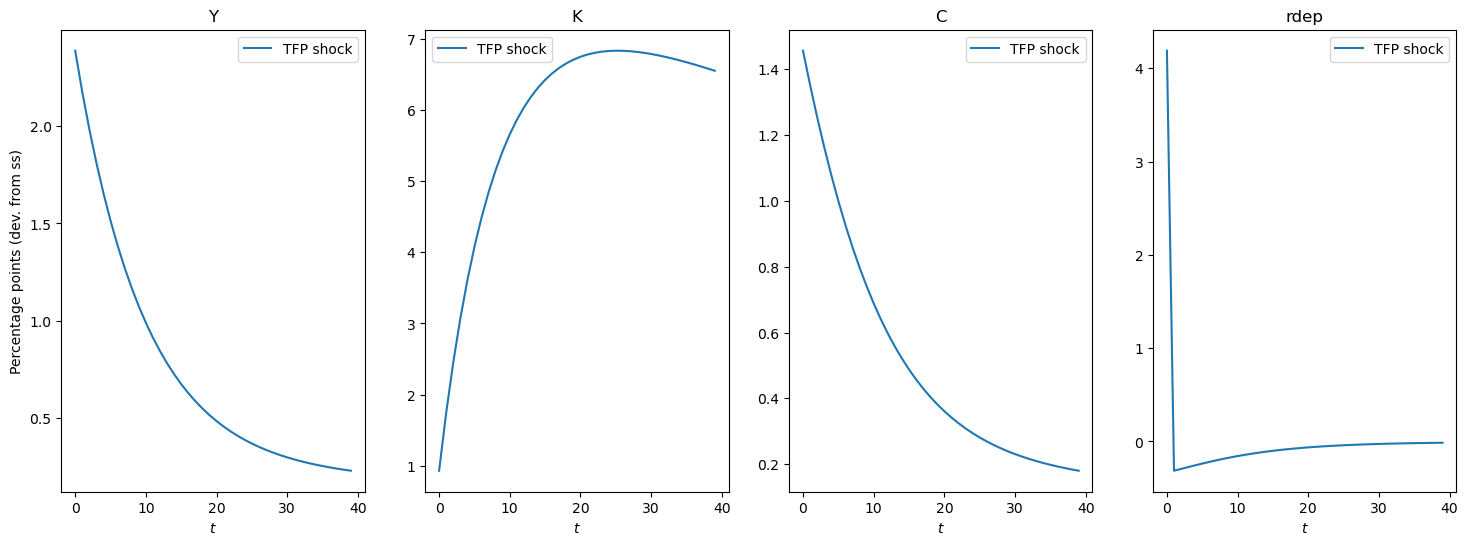

In [21]:
show_irfs([irfs], ['Y', 'K', 'C', 'rdep'],
          labels=['TFP shock'])